In [21]:
%pip install keras-tcn

Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
run_on_colab = True
try:
    from google.colab import files, drive
except:
    run_on_colab = False
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.metrics import AUC
from tcn import TCN

from sklearn.preprocessing import LabelEncoder

import keras


In [23]:
# check gpu availability

# import tensorflow as tf
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [24]:
if run_on_colab:
    uploaded = files.upload()
    df = pd.read_excel(next(iter(uploaded)))
else:
    df = pd.read_excel('../data/DataBaseTCN.xlsx')

In [25]:
output_column = "Task" # Column to be used for classification

In [26]:
output_column = "Task" 

# Get unique values
unique_text = df[output_column].dropna().unique()

# Print unique text strings
print("Unique text strings in column:", unique_text)

print(df.head())  # Shows first few rows, including header row
print("Column names:", df.columns)  # Displays detected headers



Unique text strings in column: ['DCM' 'INT' 'DLS' 'SAP' 'OPR' 'RLP']
   Dist  Speed  Heading Task
0     1    3.2    219.6  DCM
1     1    2.0    221.5  DCM
2     1    2.3    219.7  DCM
3     1    2.1    226.4  DCM
4    29  105.0     71.8  DCM
Column names: Index(['Dist', 'Speed', 'Heading', 'Task'], dtype='object')


In [27]:
# find rows with NaN values in column Task
nan_rows = df[df[output_column].isna()]
print(f"Rows with NaN values in column {output_column}:")
nan_rows

Rows with NaN values in column Task:


,Dist,Speed,Heading,Task
8811,1,2.0,268.0,NaN
13005,0,0.2,62.5,NaN
50104,0,0.6,217.7,NaN
67725,0,1.1,24.1,NaN


In [28]:
df["Task"] = df["Task"].fillna("OPR")  # Fill NaN values with "opr"

# Define features (excluding label column)
features = df.drop(columns=["Task"]).values

# Encode labels if they are categorical
label_encoder = LabelEncoder()
# Fit the label encoder to the 'Task' column and transform it to numerical labels
encoded_labels = label_encoder.fit_transform(df["Task"])
# Now use the encoded labels for one-hot encoding
labels = to_categorical(encoded_labels)

print("Feature shape:", features.shape)
print("Label shape:", labels.shape)
print("Labels:", encoded_labels)

Feature shape: (127294, 3)
Label shape: (127294, 6)
Labels: [0 0 0 ... 3 3 3]


In [29]:
dict_hyperparams = {
    "lookback_window":25,  # Time steps used to look back
    "batch_size":32, # 32, 64, 100, ...
    "use_batch_norm": True, # True, False
    "optimizer": "adamw"  # "adam", "sgd", ...
    }

In [30]:
# Create sequences
x, y = [], []
lookback_window = dict_hyperparams["lookback_window"]
for i in range(lookback_window, len(labels)):
    x.append(features[i - lookback_window:i])
    y.append(labels[i])
    
x, y = np.array(x), np.array(y)

# Split into train, validation, and test sets
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print(f'{x_train.shape=}, {y_train.shape=}')
print(f'{x_val.shape=}, {y_val.shape=}')
print(f'{x_test.shape=}, {y_test.shape=}')

x_train.shape=(89088, 25, 3), y_train.shape=(89088, 6)
x_val.shape=(19090, 25, 3), y_val.shape=(19090, 6)
x_test.shape=(19091, 25, 3), y_test.shape=(19091, 6)


In [31]:
tensorboard_callback = keras.callbacks.TensorBoard(log_dir="./runs")

In [32]:
i = Input(shape=(lookback_window, features.shape[1]))
use_batch_norm = True
m = TCN(use_batch_norm=use_batch_norm)(i)
m = Dense(labels.shape[1], activation="softmax")(m)
model = Model(inputs=i, outputs=m)

model.compile(optimizer="adamw", 
              loss="categorical_crossentropy", 
              metrics=["accuracy", "precision", "recall", "f1_score", AUC(multi_label=True, num_labels=labels.shape[1])])

# to make callbacks work, use the fix from https://stackoverflow.com/questions/71935007/valueerror-expected-scalar-shape-saw-shape-1
# example of path: ~/anaconda3/envs/keras/lib/python3.12/site-packages/tensorboard/plugins/scalar/summary_v2.py
history = model.fit(x_train, y_train, 
                    validation_data=(x_val, y_val), 
                    epochs=2, 
                    batch_size=32, 
                    callbacks=[tensorboard_callback])

I0000 00:00:1746735558.038772   79723 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/2


I0000 00:00:1746735567.008890   81270 service.cc:152] XLA service 0x7f2550001dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746735567.008921   81270 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2025-05-08 23:19:27.241004: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746735568.464226   81270 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746735574.970119   81270 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2784/2784 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - accuracy: 0.6815 - auc: 0.8595 - f1_score: 0.6032 - loss: 0.9439 - precision: 0.7266 - recall: 0.6167 - val_accuracy: 0.7927 - val_auc: 0.9343 - val_f1_score: 0.7256 - val_loss: 0.6095 - val_precision: 0.8338 - val_recall: 0.7449
Epoch 2/2
2784/2784 ━━━━━━━━━━━━━━━━━━━━ 57s 21ms/step - accuracy: 0.8577 - auc: 0.9462 - f1_score: 0.7666 - loss: 0.4633 - precision: 0.8758 - recall: 0.8384 - val_accuracy: 0.8494 - val_auc: 0.9436 - val_f1_score: 0.7618 - val_loss: 0.5378 - val_precision: 0.8644 - val_recall: 0.8350


597/597 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step
Original Labels: ['DCM' 'DLS' 'INT' 'OPR' 'RLP' 'SAP']
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.67      0.78       666
           1       0.84      0.75      0.79      3567
           2       0.59      0.50      0.54       331
           3       0.89      0.94      0.92      8053
           4       0.89      0.90      0.90       595
           5       0.84      0.86      0.85      5879

    accuracy                           0.86     19091
   macro avg       0.83      0.77      0.80     19091
weighted avg       0.86      0.86      0.86     19091



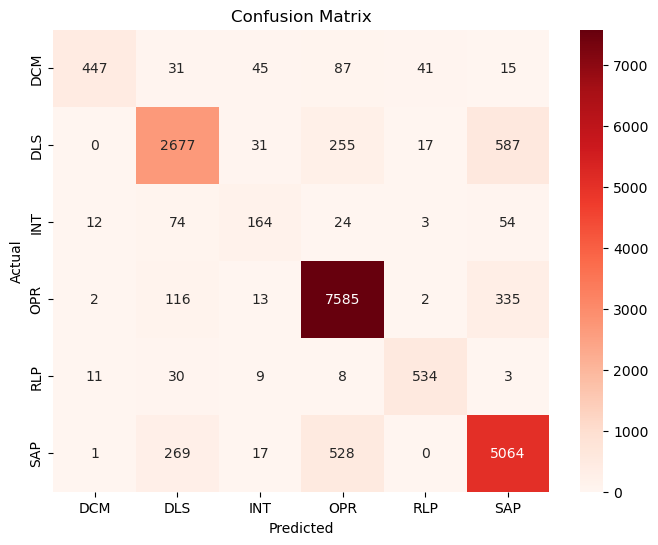

In [ ]:
# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Reverse encoding to get original names
original_labels = label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))
print("Original Labels:", original_labels)

# Classification Report
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Reds", fmt="d", xticklabels=original_labels, yticklabels=original_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

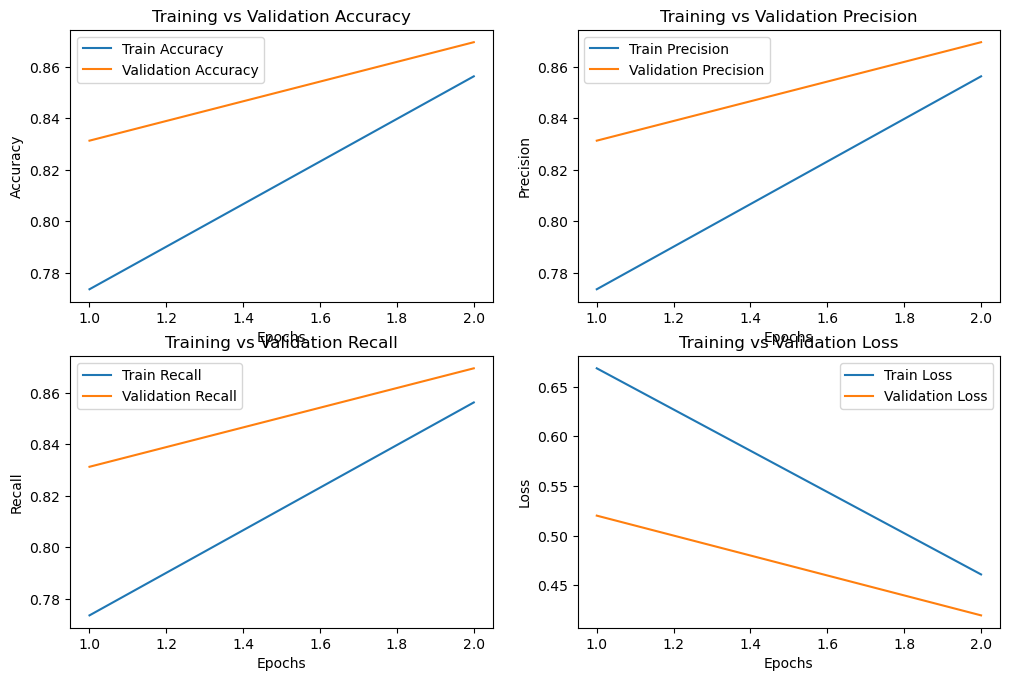

In [ ]:
import matplotlib.pyplot as plt
# history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32)
# Extract metrics
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

# Plot Accuracy
plt.figure(figsize=(12,12))
plt.subplot(2, 2, 1)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

# Plot Precision
plt.subplot(2, 2, 2)
plt.plot(epochs, train_acc, label='Train Precision')
plt.plot(epochs, val_acc, label='Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.title('Training vs Validation Precision')

# Plot Recall
plt.subplot(2, 2, 3)
plt.plot(epochs, train_acc, label='Train Recall')
plt.plot(epochs, val_acc, label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.title('Training vs Validation Recall')

# Plot Loss
plt.subplot(2, 2, 4)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'auc', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])